# This is your Python notebook
Start solving by adding a new cell below — write and run code, or jot notes in text cells as you go.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. Data Exploration
The dataset was initially explored to understand its overall structure and quality.
The analysis included:
•	Dataset shape
•	Number of rows and columns
•	Data types
•	Duplicate records
•	Numerical and categorical variables
•	Summary statistics
•	Unique values
•	Value counts
•	Potential outliers
•	Missing values
This provided an initial understanding of the dataset before performing detailed analysis.


In [ ]:
df = pd.read_csv('/content/Netflix (1).csv')

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


##To identify the unique number of directors in our dataset

In [ ]:
df['director'].nunique()

4528

##To ensure the types of contents added in Netflix
  

In [ ]:
print(df['type'].unique())

['Movie' 'TV Show']


##To identify the unique type of ratings given to the shows

In [ ]:
print(df['rating'].unique())

['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' nan 'TV-Y7-FV' 'UR']


## The date_added column in the dataset was not in a proper date format. So formatting of the column was done

In [ ]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])

##With the proper formatted date column details like day, month and year of the date_added were extracted and new columns were created for future calculations

In [ ]:
df['day'] = df['date_added'].dt.day
df['month'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.month_name()
df['Year'] = df['date_added'].dt.year

##Checking for any null values in the dataset after date formatting and extraction of day, month and year

In [ ]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


##Dropping off the null values considering show_id and title cannot be empty for a show or movie

In [ ]:
df.dropna(subset=['show_id', 'title'], inplace=True)

##Remaining empty columns were filled with appropriate fillers

In [ ]:
df.fillna({
    'director': 'Unknown',
    'cast': 'Unknown',
    'country': 'Unkown',
    'date_added': pd.NaT,
    'rating':'Unkown',
    'duration':0,
})

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,day,month,month_name,Year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",25.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unkown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24.0,9.0,September,2021.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unkown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24.0,9.0,September,2021.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24.0,9.0,September,2021.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",20.0,11.0,November,2019.0
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unkown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",1.0,7.0,July,2019.0
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,1.0,11.0,November,2019.0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",11.0,1.0,January,2020.0


##As the cast, listed_in, and country columns contained multiple values within a single row, the values were split and exploded so that each value was represented in a separate row. This transformation made it easier to perform individual-level analysis on cast members, genres, and countries.

In [ ]:
df['cast']=df['cast'].str.split(',')
df['listed_in']=df['listed_in'].str.split(',')
df['country']=df['country'].str.split(',')

In [ ]:
df=df.explode('cast')

In [ ]:
df=df.explode('country')
df=df.explode('listed_in')

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,day,month,month_name,Year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",25.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Khosi Ngema,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186399 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   show_id       186399 non-null  object        
 1   type          186399 non-null  object        
 2   title         186399 non-null  object        
 3   director      135756 non-null  object        
 4   cast          184551 non-null  object        
 5   country       175254 non-null  object        
 6   date_added    186241 non-null  datetime64[ns]
 7   release_year  186399 non-null  int64         
 8   rating        186332 non-null  object        
 9   duration      186396 non-null  object        
 10  listed_in     186399 non-null  object        
 11  description   186399 non-null  object        
 12  day           186241 non-null  float64       
 13  month         186241 non-null  float64       
 14  month_name    186241 non-null  object        
 15  Year          186241 non

In [ ]:
df['country'].value_counts()

,count
country,
United States,45452
India,20526
United Kingdom,9351
United States,8768
Japan,6854
...,...
Panama,2
Nicaragua,1
Botswana,1


In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,day,month,month_name,Year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",25.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Khosi Ngema,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0


In [ ]:
df['country']

,country
0,United States
1,South Africa
1,South Africa
1,South Africa
1,South Africa
...,...
8806,India
8806,India
8806,India
8806,India


##Trying to fetch the top 15 countries that contributed to Netflix

In [ ]:
top_country=df['country'].value_counts().head(15)

##Data Cleaning

The output showed that some country names appeared as duplicates due to inconsistent spacing and capitalization. These inconsistencies were cleaned and standardized to ensure that each country was represented consistently during analysis.

In [ ]:
top_country

,count
country,
United States,45452
India,20526
United Kingdom,9351
United States,8768
Japan,6854
South Korea,4556
Spain,4087
Canada,4072
France,3856


In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,day,month,month_name,Year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",25.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Khosi Ngema,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0


In [ ]:
df['country'].value_counts()

,count
country,
United States,45452
India,20526
United Kingdom,9351
United States,8768
Japan,6854
...,...
Panama,2
Nicaragua,1
Botswana,1


In [ ]:
df['country']=df['country'].replace(' United States', 'United States')

In [ ]:
df['country'].value_counts()

,count
country,
United States,54220
India,20526
United Kingdom,9351
Japan,6854
South Korea,4556
...,...
Panama,2
Nicaragua,1
Botswana,1


In [ ]:
df['country'] = df['country'].str.lstrip()

In [ ]:
df['country'] = df['country'].str.rstrip()

In [ ]:
df['listed_in'] = df['listed_in'].str.lstrip()
df['listed_in'] = df['listed_in'].str.rstrip()


In [ ]:
df['country'].value_counts()

,count
country,
United States,54220
India,21147
United Kingdom,12424
Japan,7940
France,7414
...,...
Afghanistan,2
Nicaragua,1
Botswana,1


##After ensuring the data is clean, now we found the top 10 countries and top 10 genres that contributed more to Netflix

In [ ]:
top_10_country = df['country'].value_counts().head(10).index

In [ ]:
top_10_genre = df['listed_in'].value_counts().head(10).index

In [ ]:
print(top_10_country)

Index(['United States', 'India', 'United Kingdom', 'Japan', 'France', 'Canada',
       'Spain', 'South Korea', 'Germany', 'Mexico'],
      dtype='object', name='country')


##Data Visualization

##Plotted a barplot showing the top 10 countries contributing to Netflix platform

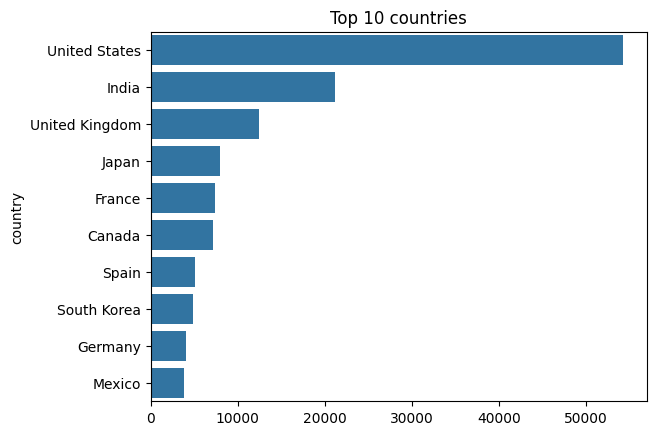

In [ ]:
country_counts = df['country'].value_counts().head(10)
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title('Top 10 countries')
plt.show()

##Inferrence:
From the graph, we can observe that the United States, India, and the United Kingdom are the top contributors to the Netflix platform in terms of content production. Among these, the United States is the dominant contributor, accounting for a significantly larger number of movies and TV shows than any other country. This indicates that the U.S. has played a major role in expanding Netflix's content library, while India and the United Kingdom also contribute substantially to the platform's diverse catalog.

##Plotted a barplot with top 10 Genre contributing to Netflix

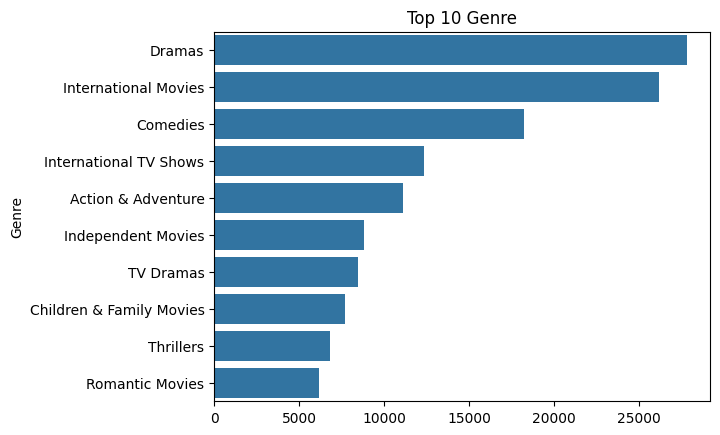

In [ ]:
genre_counts= df['listed_in'].value_counts().head(10)
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Top 10 Genre')
plt.ylabel('Genre')
plt.show()

##Inferrence:

From the above graph, we can infer that Dramas, International Movies, and Comedies are the most common genres among Netflix's movies and TV shows. Since International Movies and International TV Shows are a broad category rather than a specific genre, the popularity of Dramas, Comedies, and Action & Adventure suggests that these genres have consistently attracted a large audience. This strong viewer preference has likely encouraged content creators and streaming platforms to produce and acquire more movies and TV shows in these genres.

##Identifying the number of movies and tv shows uploaded yearly

In [ ]:
year_count= df.groupby(['Year','type']).size().reset_index(name='Count')

In [ ]:
print(year_count)

      Year     type  Count
0   2008.0    Movie     18
1   2008.0  TV Show      1
2   2009.0    Movie     30
3   2010.0    Movie     20
4   2011.0    Movie    303
5   2012.0    Movie     36
6   2013.0    Movie     74
7   2013.0  TV Show    132
8   2014.0    Movie    259
9   2014.0  TV Show    107
10  2015.0    Movie    785
11  2015.0  TV Show    435
12  2016.0    Movie   3925
13  2016.0  TV Show   3711
14  2017.0    Movie  15822
15  2017.0  TV Show   6943
16  2018.0    Movie  25713
17  2018.0  TV Show   7700
18  2019.0    Movie  30995
19  2019.0  TV Show  12158
20  2020.0    Movie  30152
21  2020.0  TV Show  12897
22  2021.0    Movie  23799
23  2021.0  TV Show  10226


##Plotted a barplot showing the number of shows added yearly

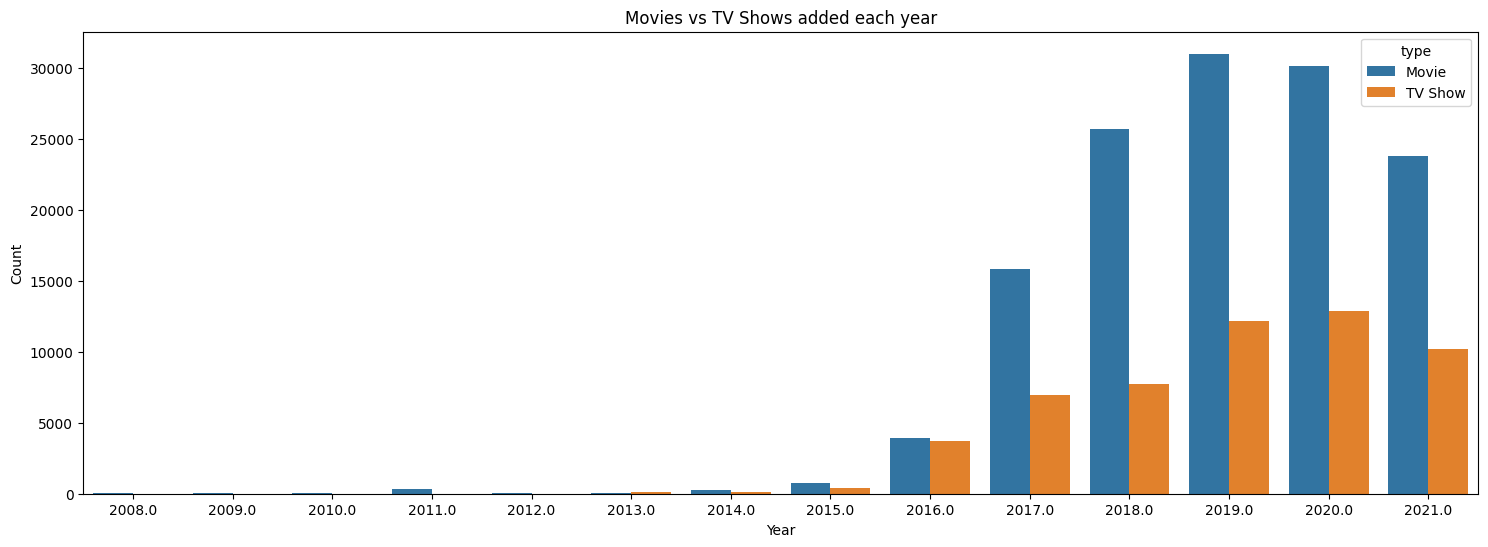

In [ ]:
plt.figure(figsize=(18, 6))
sns.barplot(
    data=year_count,
    x='Year',
    y='Count',
    hue='type'
)
plt.title ('Movies vs TV Shows added each year')
plt.show()

##Inferrence:

The above graph shows that the number of movies and TV shows added to Netflix was relatively low before 2016. From 2016 onward, the platform experienced significant growth in content additions. The number of movies added reached its peak in 2019, while 2020 recorded the highest number of TV shows added to the platform. Despite this growth, the number of TV shows remained considerably lower than the number of movies throughout the observed period, indicating that Netflix's content library has been predominantly movie-oriented.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186399 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   show_id       186399 non-null  object        
 1   type          186399 non-null  object        
 2   title         186399 non-null  object        
 3   director      135756 non-null  object        
 4   cast          184551 non-null  object        
 5   country       175254 non-null  object        
 6   date_added    186241 non-null  datetime64[ns]
 7   release_year  186399 non-null  int64         
 8   rating        186332 non-null  object        
 9   duration      186396 non-null  object        
 10  listed_in     186399 non-null  object        
 11  description   186399 non-null  object        
 12  day           186241 non-null  float64       
 13  month         186241 non-null  float64       
 14  month_name    186241 non-null  object        
 15  Year          186241 non

##Visualizing the movies and tv shows yearly on basis of the releasing year

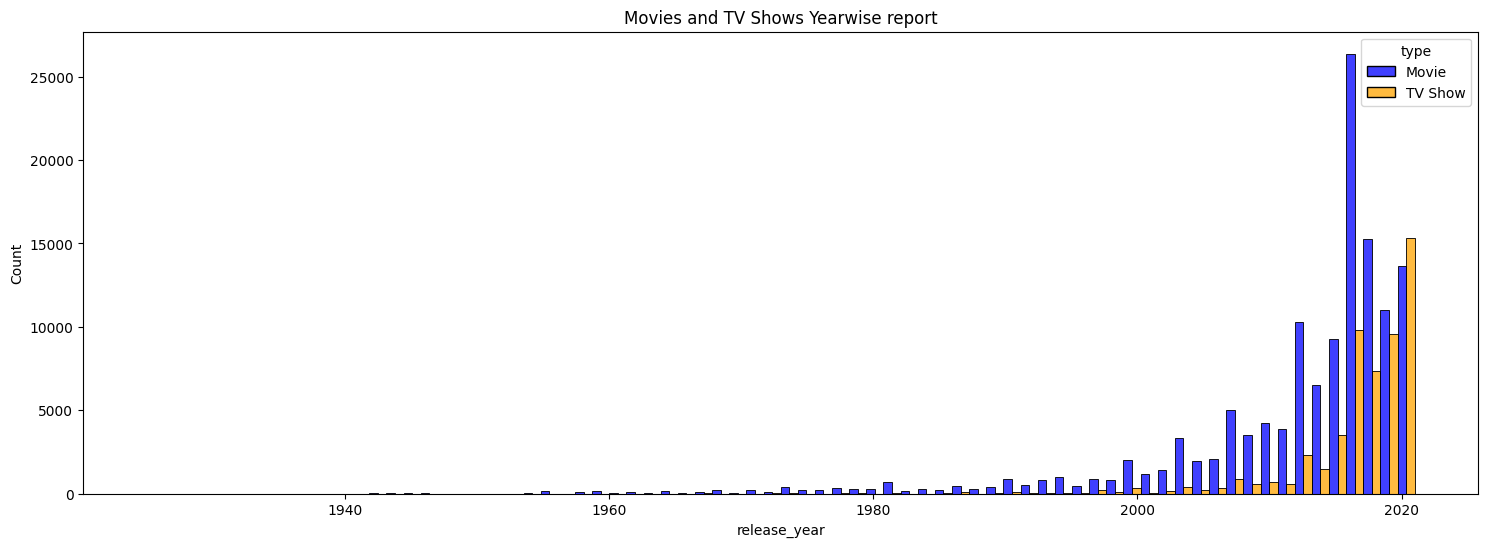

In [ ]:
plt.figure(figsize=(18, 6))
sns.histplot(
    data=df,
    x='release_year',
    hue='type',
    multiple='dodge',      # side-by-side bars
    palette=['blue', 'orange'],
    bins=len(df['release_year'].unique())
)
plt.title('Movies and TV Shows Yearwise report')
plt.show()

##Inference:

The graph shows that the production of movies experienced rapid growth during the late 2010s, reaching its peak around 2019. In contrast, TV shows saw their most significant growth in the early 2020s, with content additions peaking around 2020. This trend indicates that while Netflix initially focused on expanding its movie library, it later increased its investment in original and licensed TV shows.

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,day,month,month_name,Year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",25.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0
1,s2,TV Show,Blood & Water,NaN,Khosi Ngema,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",24.0,9.0,September,2021.0


##Identifying the Best Months for Netflix Content Additions Across All Years

In [ ]:
best_months = df.groupby('month_name').size().sort_values(ascending=False)

In [ ]:
best_months

,0
month_name,
July,18028
January,16985
December,16933
September,16826
October,16161
August,15848
April,15473
June,15413
March,15228


##Plotted the month wise report

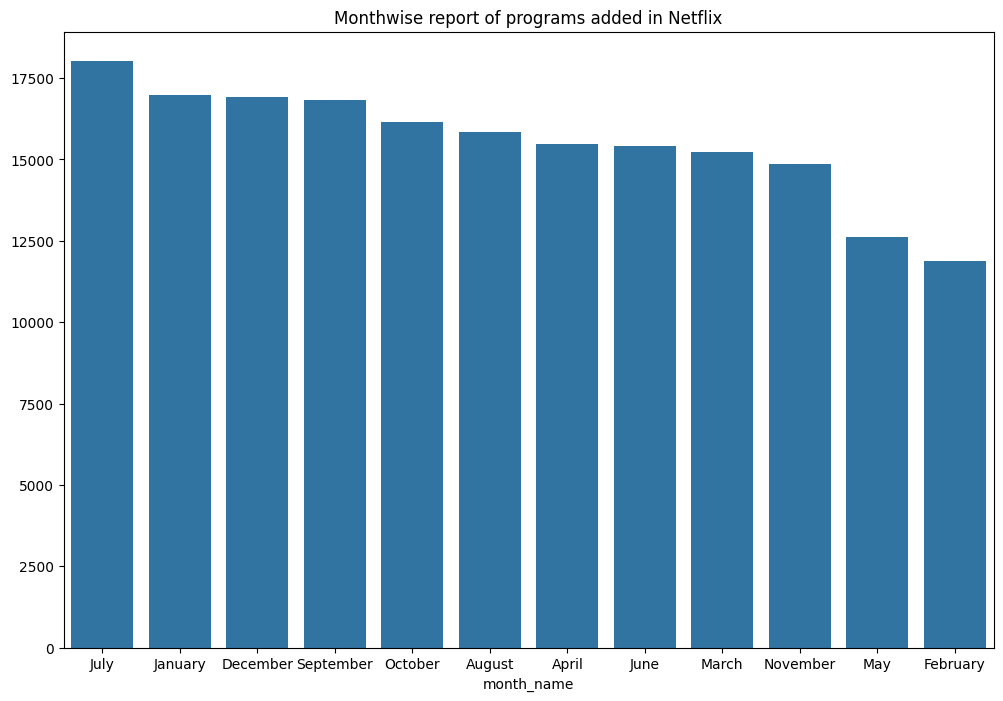

In [ ]:
plt.figure(figsize=(12,8))
sns.barplot(x=best_months.index,y = best_months.values)
plt.title('Monthwise report of programs added in Netflix')
plt.show()

##Inference:

From the above bar chart, we can observe that July is the peak month for adding both movies and TV shows to the Netflix platform. The months of January, December, and September follow July in terms of content additions. Since there is no significant difference among these three months, we can conclude that January, December, and September are also favorable periods for Netflix content releases. These months appear to be strategically important periods when a higher number of movies and TV shows are added to the platform.

##Business Insights:



1.   We can observe a considerable increase in the number of TV shows added to Netflix in recent years. However, the total count of TV shows remains significantly lower compared to movies. The dataset contains 131,931 movies and 54,468 TV shows, indicating that TV shows account for less than half of the movie content available on the platform.
2. The number of movies added to Netflix experienced a slight decline after 2019. This decrease may be associated with the impact of the COVID-19 pandemic, which disrupted global content production and release schedules. Since the dataset contains records only up to 2021, which was the later phase of the pandemic, further analysis with post-2021 data may reveal a recovery and growth in content additions.
3. The months of February, January, December, and September appear to be the peak periods for content additions on Netflix, with 2019 being identified as the peak year for overall content growth. This indicates that Netflix may have strategically focused on releasing more movies and TV shows during these periods to maximize audience engagement.



##Business Recommendations:


1. Include data beyond 2021 to evaluate Netflix's current growth trajectory and determine whether the platform continues to be in an expansion phase after the impact of the COVID-19 pandemic.
2. Increase the production and acquisition of TV shows, as the growing demand for series content indicates a potential opportunity for future growth and improved audience retention.
3. Focus on popular genres such as Drama, Comedy, and Action & Adventure by adding more content in these categories, as these genres have shown strong audience preference and could contribute to higher viewer engagement and platform growth.




